# Ablation Study: Statistical Significance Testing

Compares model performance (F1 and AUC) across three conditions for all six B. rapa models:
- **All Features**: full feature set including recombination rate
- **No Recomb**: all features except recombination rate
- **Only Recomb**: recombination rate as the sole feature

**Statistical tests used:**
- F1: paired t-test on per-fold scores (10 folds, matched by fold index)
- AUC: DeLong test on raw predicted probabilities (paired, same samples across conditions)
- Multiple testing correction: Benjamini-Hochberg FDR applied within each group
  independently and separately for each metric (3 tests per metric per group:
  3 comparisons; 6 groups x 2 metrics = 12 correction families of 3)

**Correction rationale:** FDR correction is applied within each group and separately
for F1 and AUC because these metrics are measured by different statistical tests on
different data structures and represent distinct inferential families. Penalising tests
in one group for what happens in another, or mixing test types within the same
correction pool, is not appropriate given the within-dataset scope of the question.
This mirrors the correction strategy used for the benchmarking bar charts.

**Comparisons:** All Features vs. No Recomb; All Features vs. Only Recomb; No Recomb vs. Only Recomb

**Note on hyperparameters:** Hyperparameters were tuned on the full feature set and held
fixed across all ablation conditions. This isolates the marginal contribution of recombination
rate without confounding from re-optimization.

In [11]:
# ============================================================
# CELL 1: IMPORTS
# ============================================================
import os
import numpy as np
import pandas as pd
from scipy.stats import norm, ttest_rel
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print('Imports complete.')

Imports complete.


In [12]:
# ============================================================
# CELL 2: CONFIGURATION
# ============================================================

from pathlib import Path

OUTPUT_DIR = Path("../brassica_outputs/ablation_stats")
os.makedirs(OUTPUT_DIR, exist_ok=True)

DIR_ALL_FEATURES = Path("../brassica_outputs/model_outputs")
DIR_NO_RECOMB    = Path("../brassica_outputs/model_outputs_no_recomb")
DIR_RECOMB_ONLY  = Path("../brassica_outputs/model_outputs_recomb_only")

# Groups — one entry per PAIR × USE_GROUP1 configuration
# Tags match the PREFIX convention used in all three model notebooks:
# f"{PAIR}_{'groupI' if USE_GROUP1 else 'all'}"
GROUPS = [
    "lf_mf1_all",    "lf_mf1_groupI",
    "lf_mf2_all",    "lf_mf2_groupI",
    "mf1_mf2_all",   "mf1_mf2_groupI",
]

GROUP_LABELS = {
    "lf_mf1_all":    "LF\u2013MF1 (All)",
    "lf_mf1_groupI": "LF\u2013MF1 (Group I)",
    "lf_mf2_all":    "LF\u2013MF2 (All)",
    "lf_mf2_groupI": "LF\u2013MF2 (Group I)",
    "mf1_mf2_all":   "MF1\u2013MF2 (All)",
    "mf1_mf2_groupI":"MF1\u2013MF2 (Group I)",
}

# Conditions: label, directory, filename suffix, and plot color
CONDITIONS = {
    "all_features": {
        "dir":    DIR_ALL_FEATURES,
        "suffix": "",              # prefix = f"{GROUP}"
        "label":  "All Features",
        "color":  "#4472C4"        # blue
    },
    "no_recomb": {
        "dir":    DIR_NO_RECOMB,
        "suffix": "_no_recomb",
        "label":  "No Recomb",
        "color":  "#ED7D31"        # orange
    },
    "recomb_only": {
        "dir":    DIR_RECOMB_ONLY,
        "suffix": "_recomb_only",
        "label":  "Only Recomb",
        "color":  "#70AD47"        # green
    }
}

# Comparisons to test (reference condition is always all_features)
COMPARISONS = [
    ("all_features", "no_recomb",   "All vs. No Recomb"),
    ("all_features", "recomb_only", "All vs. Only Recomb"),
    ("no_recomb",    "recomb_only", "No Recomb vs. Only Recomb")
]

print(f"Output directory : {OUTPUT_DIR}")
print(f"Groups           : {GROUPS}")
print(f"Conditions       : {list(CONDITIONS.keys())}")
print(f"Comparisons      : {[c[2] for c in COMPARISONS]}")

Output directory : /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_ablation_stats
Groups           : ['lf_mf1_all', 'lf_mf1_groupI', 'lf_mf2_all', 'lf_mf2_groupI', 'mf1_mf2_all', 'mf1_mf2_groupI']
Conditions       : ['all_features', 'no_recomb', 'recomb_only']
Comparisons      : ['All vs. No Recomb', 'All vs. Only Recomb', 'No Recomb vs. Only Recomb']


In [13]:
# ============================================================
# CELL 3: HELPER FUNCTIONS
# ============================================================

def get_prefix(group, suffix):
    """Construct the file prefix for a given group and condition suffix."""
    return f"{group}{suffix}"


def delong_test_paired(y_true, scores_a, scores_b):
    """
    DeLong test for comparing two paired AUC values.

    Implements the nonparametric method from:
    DeLong et al. (1988) Biometrics 44(3):837-845.

    Because both models were evaluated on the same set of genes, the
    test accounts for the correlation between AUC estimates via the
    covariance of the structural components (placement values).

    Parameters
    ----------
    y_true   : array-like, binary true labels (0 or 1)
    scores_a : array-like, predicted probabilities from model A
    scores_b : array-like, predicted probabilities from model B

    Returns
    -------
    auc_a   : float — AUC for model A
    auc_b   : float — AUC for model B
    z       : float — DeLong z-statistic
    p_value : float — two-tailed p-value (not FDR-corrected)
    """
    y_true   = np.asarray(y_true)
    scores_a = np.asarray(scores_a)
    scores_b = np.asarray(scores_b)

    pos_mask = y_true == 1
    neg_mask = y_true == 0

    pos_a = scores_a[pos_mask]
    neg_a = scores_a[neg_mask]
    pos_b = scores_b[pos_mask]
    neg_b = scores_b[neg_mask]

    n = len(pos_a)   # number of positives
    m = len(neg_a)   # number of negatives

    assert n > 1 and m > 1, \
        f"DeLong test requires >1 positive and >1 negative. Got n={n}, m={m}."

    # --- Vectorized placement values ---
    # V10[i]: for positive i, fraction of negatives scored strictly lower
    #         + 0.5 * fraction scored equal (handles ties)
    def v10(pos, neg):
        diff = pos[:, np.newaxis] - neg[np.newaxis, :]   # (n, m)
        return np.mean(diff > 0, axis=1) + 0.5 * np.mean(diff == 0, axis=1)

    # V01[j]: for negative j, fraction of positives scored strictly higher
    #         + 0.5 * fraction scored equal
    def v01(pos, neg):
        diff = pos[:, np.newaxis] - neg[np.newaxis, :]   # (n, m)
        return np.mean(diff > 0, axis=0) + 0.5 * np.mean(diff == 0, axis=0)

    v10_a = v10(pos_a, neg_a)   # length n
    v01_a = v01(pos_a, neg_a)   # length m
    v10_b = v10(pos_b, neg_b)
    v01_b = v01(pos_b, neg_b)

    auc_a = float(np.mean(v10_a))
    auc_b = float(np.mean(v10_b))

    # --- 2x2 covariance matrices of placement value vectors ---
    # np.cov divides by n-1 (sample covariance), which is correct here.
    # The DeLong formula divides these by n (for V10) and m (for V01)
    # to obtain the covariance matrix of the AUC estimates.
    cov10 = np.cov(np.vstack([v10_a, v10_b]))   # 2x2
    cov01 = np.cov(np.vstack([v01_a, v01_b]))   # 2x2

    # Covariance matrix of (AUC_a, AUC_b)
    S = cov10 / n + cov01 / m

    # Variance of the difference (AUC_a - AUC_b)
    var_diff = S[0, 0] + S[1, 1] - 2 * S[0, 1]

    if var_diff <= 0:
        print(f"  WARNING: var_diff={var_diff:.6e}. Returning NaN for z and p.")
        return auc_a, auc_b, np.nan, np.nan

    z       = (auc_a - auc_b) / np.sqrt(var_diff)
    p_value = float(2 * (1 - norm.cdf(abs(z))))

    return auc_a, auc_b, z, p_value


def p_to_stars(p_corrected):
    """Convert FDR-corrected p-value to significance notation."""
    if np.isnan(p_corrected):
        return 'n/a'
    elif p_corrected <= 0.001:
        return '***'
    elif p_corrected <= 0.01:
        return '**'
    elif p_corrected <= 0.05:
        return '*'
    else:
        return 'ns'


def draw_bracket(ax, x1, x2, y, h, text, fontsize=11, lw=1.2):
    """
    Draw a significance bracket between x-positions x1 and x2
    at height y, with a tick of height h, annotated with text.
    """
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y],
            lw=lw, color='black', clip_on=False)
    ax.text((x1 + x2) / 2, y + h * 1.15, text,
            ha='center', va='bottom', fontsize=fontsize, color='black')


print('Helper functions defined.')

Helper functions defined.


In [14]:
# ============================================================
# CELL 4: LOAD ALL DATA
# ============================================================
# fold_f1_data[group][condition]    -> np.array of 10 F1 scores, sorted by fold
# probas_data[group][condition]     -> dict with keys 'y_true', 'pred_proba'
fold_f1_data  = {g: {} for g in GROUPS}
fold_auc_data = {g: {} for g in GROUPS}
probas_data   = {g: {} for g in GROUPS}

for group in GROUPS:
    for cond_key, cond in CONDITIONS.items():
        prefix = get_prefix(group, cond["suffix"])

        # --- Per-fold F1 ---
        f1_path = os.path.join(cond["dir"], f"{prefix}_fold_f1.csv")
        assert os.path.exists(f1_path), \
            f"MISSING: {f1_path}"
        f1_df = pd.read_csv(f1_path).sort_values("fold").reset_index(drop=True)
        assert len(f1_df) == 10, \
            f"Expected 10 folds in {f1_path}, got {len(f1_df)}."
        fold_f1_data[group][cond_key] = f1_df["f1"].values

        # --- Per-fold AUC ---
        auc_path = os.path.join(cond["dir"], f"{prefix}_fold_auc.csv")
        assert os.path.exists(auc_path), \
            f"MISSING: {auc_path}"
        auc_df = pd.read_csv(auc_path).sort_values("fold").reset_index(drop=True)
        assert len(auc_df) == 10, \
            f"Expected 10 folds in {auc_path}, got {len(auc_df)}."
        fold_auc_data[group][cond_key] = auc_df["auc"].values

        # --- Predicted probabilities ---
        probas_path = os.path.join(cond["dir"], f"{prefix}_predicted_probas.csv")
        assert os.path.exists(probas_path), \
            f"MISSING: {probas_path}"
        probas_df = pd.read_csv(probas_path)
        assert "true_label" in probas_df.columns and "pred_proba" in probas_df.columns, \
            f"Expected columns 'true_label' and 'pred_proba' in {probas_path}."
        probas_data[group][cond_key] = {
            "y_true":     probas_df["true_label"].values,
            "pred_proba": probas_df["pred_proba"].values
        }
        print(f"  Loaded group {group:>15} | {cond_key:<15} "
              f"| n_genes={len(probas_df):>5} "
              f"| mean_F1={fold_f1_data[group][cond_key].mean():.3f}")

print('\nAll data loaded successfully.')

  Loaded group      lf_mf1_all | all_features    | n_genes= 4724 | mean_F1=0.703
  Loaded group      lf_mf1_all | no_recomb       | n_genes= 4724 | mean_F1=0.558
  Loaded group      lf_mf1_all | recomb_only     | n_genes= 4724 | mean_F1=0.688
  Loaded group   lf_mf1_groupI | all_features    | n_genes= 4072 | mean_F1=0.707
  Loaded group   lf_mf1_groupI | no_recomb       | n_genes= 4072 | mean_F1=0.561
  Loaded group   lf_mf1_groupI | recomb_only     | n_genes= 4072 | mean_F1=0.693
  Loaded group      lf_mf2_all | all_features    | n_genes= 3986 | mean_F1=0.777
  Loaded group      lf_mf2_all | no_recomb       | n_genes= 3986 | mean_F1=0.564
  Loaded group      lf_mf2_all | recomb_only     | n_genes= 3986 | mean_F1=0.775
  Loaded group   lf_mf2_groupI | all_features    | n_genes= 3176 | mean_F1=0.780
  Loaded group   lf_mf2_groupI | no_recomb       | n_genes= 3176 | mean_F1=0.567
  Loaded group   lf_mf2_groupI | recomb_only     | n_genes= 3176 | mean_F1=0.781
  Loaded group     mf1_mf2_a

In [15]:
# ============================================================
# CELL 5: STATISTICAL TESTS
# Run paired t-tests (F1) and DeLong tests (AUC) for each
# group and comparison. Collect raw p-values for FDR correction.
# ============================================================

# Storage for raw test results before FDR correction
# Each entry: dict with group, comparison, metric, statistic, p_raw, and supporting values
raw_results = []

# AUC bootstrapped values for plotting (computed here, used in Cell 7)
auc_summary = {g: {} for g in GROUPS}   # auc_summary[group][condition] = (mean, std)

for group in GROUPS:
    print(f"\n{'='*55}")
    print(f"Group {group} — {GROUP_LABELS[group]}")
    print(f"{'='*55}")

    # --- Per-fold AUC summary for all three conditions (for bar plot) ---
    for cond_key in CONDITIONS:
        auc_scores = fold_auc_data[group][cond_key]
        auc_mean   = float(np.mean(auc_scores))
        auc_std    = float(np.std(auc_scores))
        auc_summary[group][cond_key] = (auc_mean, auc_std)
        print(f"  {cond_key:<15} per-fold AUC = {auc_mean:.4f} ± {auc_std:.4f}")

    # --- Run tests for each comparison ---
    for cond_a, cond_b, comp_label in COMPARISONS:
        print(f"\n  Comparison: {comp_label}")

        # Paired t-test on per-fold F1 scores
        f1_a = fold_f1_data[group][cond_a]
        f1_b = fold_f1_data[group][cond_b]
        t_stat, p_f1 = ttest_rel(f1_a, f1_b)
        mean_diff_f1 = float(np.mean(f1_a - f1_b))
        print(f"    F1  paired t-test: t={t_stat:.4f}, p={p_f1:.4e}, "
              f"mean diff={mean_diff_f1:+.4f}")

        raw_results.append({
            "group":       group,
            "comparison":  comp_label,
            "metric":      "F1",
            "cond_a":      cond_a,
            "cond_b":      cond_b,
            "value_a":     float(np.mean(f1_a)),
            "value_b":     float(np.mean(f1_b)),
            "mean_diff":   mean_diff_f1,
            "statistic":   float(t_stat),
            "p_raw":       float(p_f1)
        })

        # DeLong test on raw predicted probabilities
        yt_a = probas_data[group][cond_a]["y_true"]
        pp_a = probas_data[group][cond_a]["pred_proba"]
        pp_b = probas_data[group][cond_b]["pred_proba"]
        # y_true must be identical across conditions (same genes)
        yt_b = probas_data[group][cond_b]["y_true"]
        assert np.array_equal(yt_a, yt_b), \
            f"CRITICAL: true labels differ between {cond_a} and {cond_b} for group {group}."

        auc_a_dl, auc_b_dl, z_dl, p_auc = delong_test_paired(yt_a, pp_a, pp_b)
        print(f"    AUC DeLong test : z={z_dl:.4f}, p={p_auc:.4e}, "
              f"AUC_a={auc_a_dl:.4f}, AUC_b={auc_b_dl:.4f}")

        raw_results.append({
            "group":      group,
            "comparison": comp_label,
            "metric":     "AUC",
            "cond_a":     cond_a,
            "cond_b":     cond_b,
            "value_a":    auc_a_dl,
            "value_b":    auc_b_dl,
            "mean_diff":  float(auc_a_dl - auc_b_dl),
            "statistic":  float(z_dl),
            "p_raw":      float(p_auc)
        })

print(f"\nTotal tests collected: {len(raw_results)} (expected 36)")


Group lf_mf1_all — LF–MF1 (All)
  all_features    per-fold AUC = 0.7647 ± 0.0197
  no_recomb       per-fold AUC = 0.5890 ± 0.0201
  recomb_only     per-fold AUC = 0.7633 ± 0.0225

  Comparison: All vs. No Recomb
    F1  paired t-test: t=28.6731, p=3.7176e-10, mean diff=+0.1451
    AUC DeLong test : z=21.4256, p=0.0000e+00, AUC_a=0.7646, AUC_b=0.5847

  Comparison: All vs. Only Recomb
    F1  paired t-test: t=3.3715, p=8.2368e-03, mean diff=+0.0146
    AUC DeLong test : z=0.9309, p=3.5191e-01, AUC_a=0.7646, AUC_b=0.7606

  Comparison: No Recomb vs. Only Recomb
    F1  paired t-test: t=-19.6740, p=1.0495e-08, mean diff=-0.1305
    AUC DeLong test : z=-16.4802, p=0.0000e+00, AUC_a=0.5847, AUC_b=0.7606

Group lf_mf1_groupI — LF–MF1 (Group I)
  all_features    per-fold AUC = 0.7723 ± 0.0322
  no_recomb       per-fold AUC = 0.5755 ± 0.0279
  recomb_only     per-fold AUC = 0.7793 ± 0.0281

  Comparison: All vs. No Recomb
    F1  paired t-test: t=23.7546, p=1.9817e-09, mean diff=+0.1458
    A

In [16]:
# ============================================================
# CELL 6: FDR CORRECTION AND SUMMARY TABLE
#
# Benjamini-Hochberg FDR correction is applied WITHIN each
# group AND separately for each metric (3 tests per family:
# 3 comparisons x 1 metric).
#
# Rationale: F1 and AUC are measured by different statistical
# tests on different data structures (per-fold t-test vs.
# pooled DeLong) and represent distinct inferential families.
# Mixing them in the same correction pool is not appropriate.
# Correction is also scoped within each group because the
# question is whether recombination matters within each
# dataset — not across datasets. This mirrors the correction
# strategy used for the benchmarking bar charts.
# ============================================================

results_df = pd.DataFrame(raw_results)

# Initialise corrected p-value and reject columns
results_df["p_corrected"] = np.nan
results_df["reject_H0"]   = False

for group in GROUPS:
    for metric in ["F1", "AUC"]:

        # Boolean mask selecting the 3 tests for this group x metric family
        family_mask = (
            (results_df["group"]  == group) &
            (results_df["metric"] == metric)
        )

        # Raw p-values for the 3 comparisons in this family
        p_raw_family = results_df.loc[family_mask, "p_raw"].values

        # BH FDR correction within this family of 3 tests only
        reject_family, p_corr_family, _, _ = multipletests(
            p_raw_family, method="fdr_bh"
        )

        # Write corrected values back into the full DataFrame
        results_df.loc[family_mask, "p_corrected"] = p_corr_family
        results_df.loc[family_mask, "reject_H0"]   = reject_family

results_df["significance"] = results_df["p_corrected"].apply(p_to_stars)

# Round for readability
for col in ["value_a", "value_b", "mean_diff", "statistic", "p_raw", "p_corrected"]:
    results_df[col] = results_df[col].round(6)

# Display
display_cols = ["group", "metric", "comparison", "value_a", "value_b",
                "mean_diff", "statistic", "p_raw", "p_corrected", "significance"]
print(results_df[display_cols].to_string(index=False))

# Save
out_path = os.path.join(OUTPUT_DIR, "ablation_significance_results.csv")
results_df[display_cols].to_csv(out_path, index=False)
print(f"\nSummary table saved to: {out_path}")

         group metric                comparison  value_a  value_b  mean_diff  statistic    p_raw  p_corrected significance
    lf_mf1_all     F1         All vs. No Recomb 0.702677 0.557615   0.145063  28.673080 0.000000     0.000000          ***
    lf_mf1_all    AUC         All vs. No Recomb 0.764557 0.584726   0.179830  21.425639 0.000000     0.000000          ***
    lf_mf1_all     F1       All vs. Only Recomb 0.702677 0.688080   0.014598   3.371538 0.008237     0.008237           **
    lf_mf1_all    AUC       All vs. Only Recomb 0.764557 0.760577   0.003980   0.930890 0.351911     0.351911           ns
    lf_mf1_all     F1 No Recomb vs. Only Recomb 0.557615 0.688080  -0.130465 -19.673961 0.000000     0.000000          ***
    lf_mf1_all    AUC No Recomb vs. Only Recomb 0.584726 0.760577  -0.175851 -16.480242 0.000000     0.000000          ***
 lf_mf1_groupI     F1         All vs. No Recomb 0.707245 0.561446   0.145799  23.754555 0.000000     0.000000          ***
 lf_mf1_groupI  

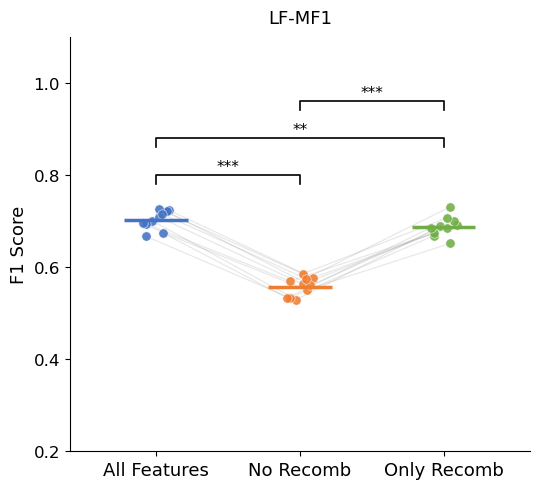

Saved F1 strip plot for Group lf_mf1_all


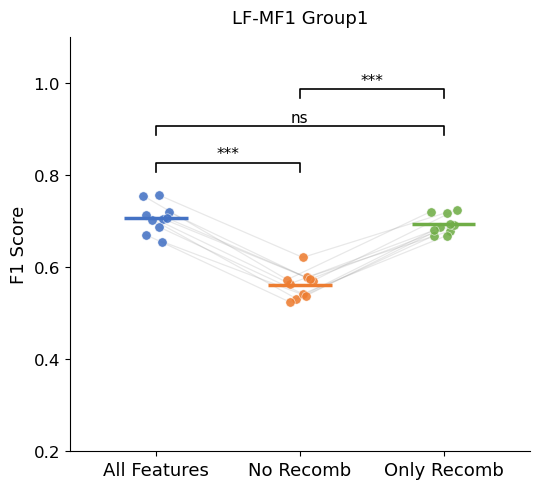

Saved F1 strip plot for Group lf_mf1_groupI


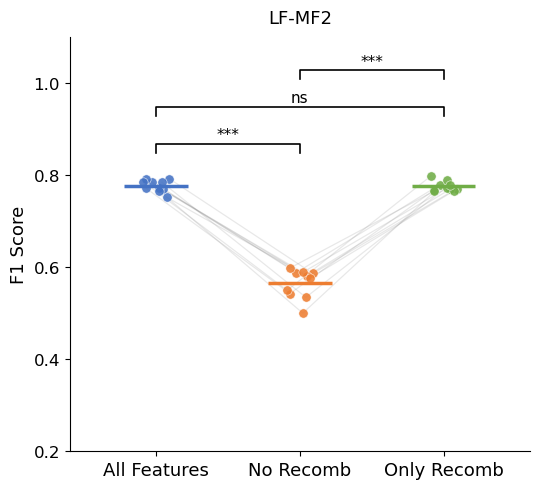

Saved F1 strip plot for Group lf_mf2_all


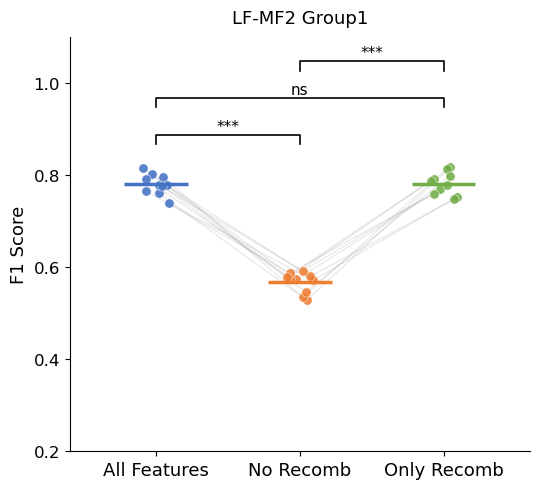

Saved F1 strip plot for Group lf_mf2_groupI


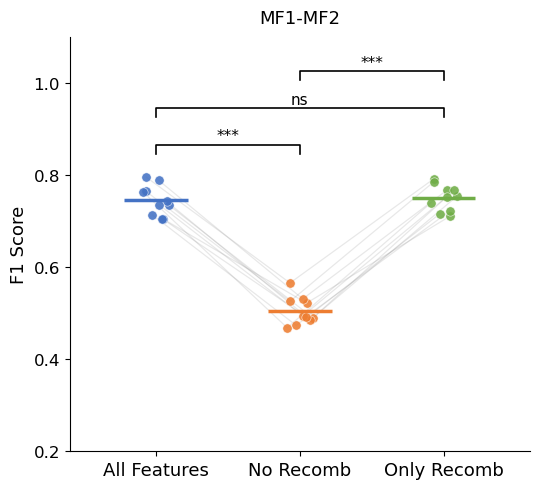

Saved F1 strip plot for Group mf1_mf2_all


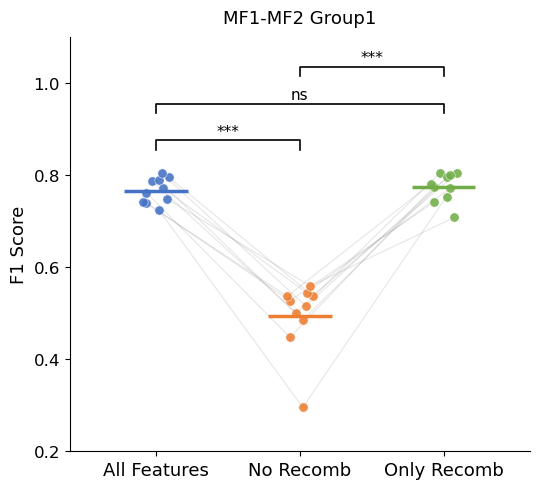

Saved F1 strip plot for Group mf1_mf2_groupI

All F1 strip plots saved.


In [20]:
# ============================================================
# CELL 7: F1 STRIP PLOTS — one figure per group
#
# Shows per-fold F1 scores (10 points per condition) with
# thin gray lines connecting matching folds across conditions
# to make the paired structure explicit. Mean shown as a
# horizontal bar. Significance brackets use FDR-corrected p.
# ============================================================

CONDITION_KEYS   = ["all_features", "no_recomb", "recomb_only"]
CONDITION_LABELS = [CONDITIONS[c]["label"] for c in CONDITION_KEYS]
CONDITION_COLORS = [CONDITIONS[c]["color"] for c in CONDITION_KEYS]
X_POSITIONS      = [0, 1, 2]

RANDOM_STATE = 42

# Fixed jitter for all conditions so connecting lines are straight
rng    = np.random.RandomState(RANDOM_STATE)
JITTER = rng.uniform(-0.10, 0.10, 10)

title_names = [
    "LF-MF1", "LF-MF1 Group1", 
    "LF-MF2", "LF-MF2 Group1",
    "MF1-MF2", "MF1-MF2 Group1"
]

for group, custom_title in zip(GROUPS, title_names):

    fig, ax = plt.subplots(figsize=(5.5, 5))

    # Collect y-values per condition for bracket positioning
    all_f1_vals = np.concatenate([fold_f1_data[group][c] for c in CONDITION_KEYS])
    y_min = all_f1_vals.min()
    y_max = all_f1_vals.max()
    y_range = y_max - y_min

    # --- Gray lines connecting matching folds (pairing visualization) ---
    for fold_i in range(10):
        y_vals = [fold_f1_data[group][c][fold_i] for c in CONDITION_KEYS]
        x_vals = [x + JITTER[fold_i] for x in X_POSITIONS]
        ax.plot(x_vals, y_vals, color='gray', alpha=0.18, lw=0.9, zorder=1)

    # --- Scatter points and mean bars ---
    for i, (cond_key, color) in enumerate(zip(CONDITION_KEYS, CONDITION_COLORS)):
        y_vals = fold_f1_data[group][cond_key]
        x_vals = X_POSITIONS[i] + JITTER
        ax.scatter(x_vals, y_vals,
                   color=color, s=45, zorder=3, alpha=0.88,
                   edgecolors='white', linewidths=0.4)
        mean_val = np.mean(y_vals)
        ax.hlines(mean_val,
                  X_POSITIONS[i] - 0.22, X_POSITIONS[i] + 0.22,
                  colors=color, linewidths=2.5, zorder=4)

    # --- Significance Section: Consistent spacing ---
    # Use fixed absolute values for vertical gaps since Y-axis is now fixed (0.4 to 1.3)
    bracket_pad = 0.05  # Initial lift above the highest data point
    gap         = 0.08  # Consistent vertical distance between brackets
    tick_h      = 0.02  # Consistent height for the bracket "ticks"

    # 1. All Features vs No Recomb (Bottom Bracket)
    row_1 = results_df[
        (results_df.group == group) & (results_df.metric == "F1") & (results_df.cond_b == "no_recomb")
    ].iloc[0]
    y1 = y_max + bracket_pad
    draw_bracket(ax, 0, 1, y1, tick_h, row_1["significance"]) 

    # 2. All Features vs Only Recomb (Middle Bracket)
    row_2 = results_df[
        (results_df.group == group) & (results_df.metric == "F1") & (results_df.cond_b == "recomb_only")
    ].iloc[0]
    y2 = y1 + gap
    draw_bracket(ax, 0, 2, y2, tick_h, row_2["significance"]) 

    # 3. No Recomb vs Only Recomb (Top Bracket)
    row_3 = results_df[
        (results_df.group == group) & (results_df.metric == "F1") & 
        (results_df.cond_a == "no_recomb") & (results_df.cond_b == "recomb_only")
    ].iloc[0]
    y3 = y2 + gap
    draw_bracket(ax, 1, 2, y3, tick_h, row_3["significance"]) 

    # --- Axes formatting ---
    ax.set_xticks(X_POSITIONS)
    ax.set_xticklabels(CONDITION_LABELS, fontsize=13)
    ax.set_ylabel('F1 Score', fontsize=13)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_title(custom_title, fontsize=13, pad=10) 
    ax.set_xlim(-0.6, 2.6)

    # --- Set a fixed upper limit (e.g., 1.3) to fit brackets 
    # and manually define ticks to stop at 1.0
    ax.set_ylim(0.2, 1.1) 
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    for ext in ['pdf', 'png']:
        fig.savefig(
            os.path.join(OUTPUT_DIR, f"{group}_f1_strip.{ext}"),
            dpi=300, bbox_inches='tight'
        )
    plt.show()
    plt.close()
    print(f"Saved F1 strip plot for Group {group}")

print('\nAll F1 strip plots saved.')

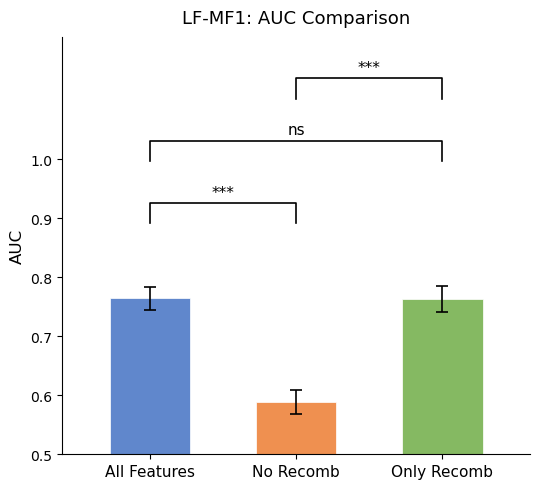

Saved AUC bar plot for Group lf_mf1_all


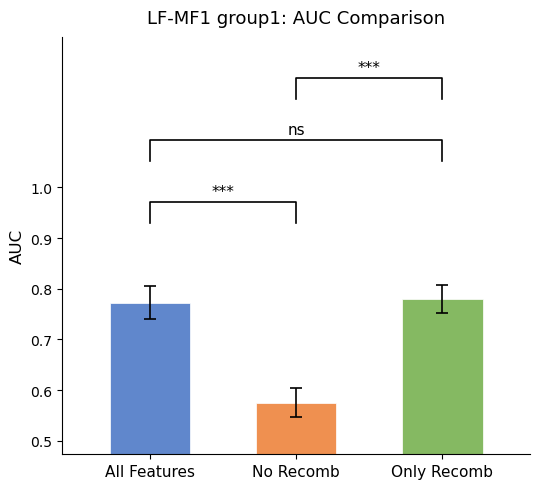

Saved AUC bar plot for Group lf_mf1_groupI


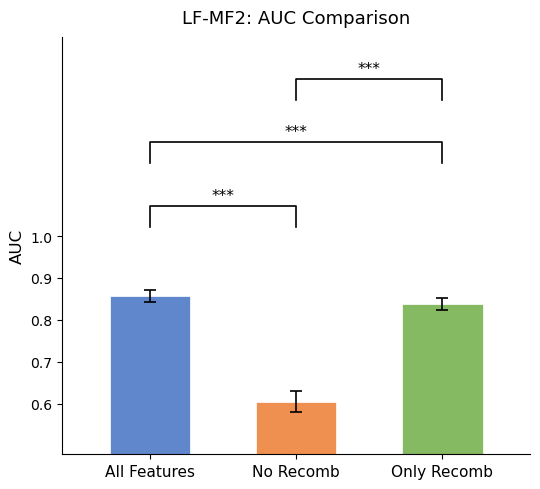

Saved AUC bar plot for Group lf_mf2_all


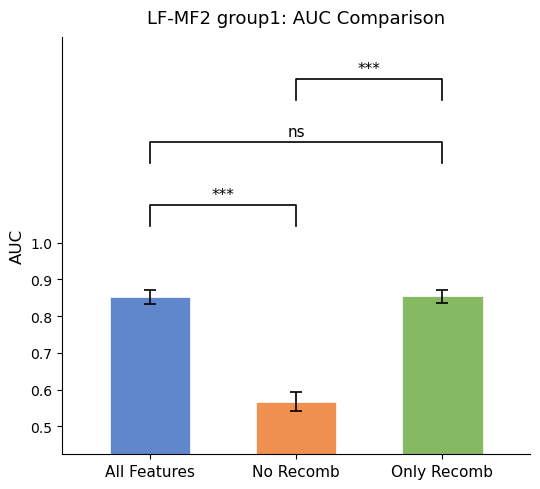

Saved AUC bar plot for Group lf_mf2_groupI


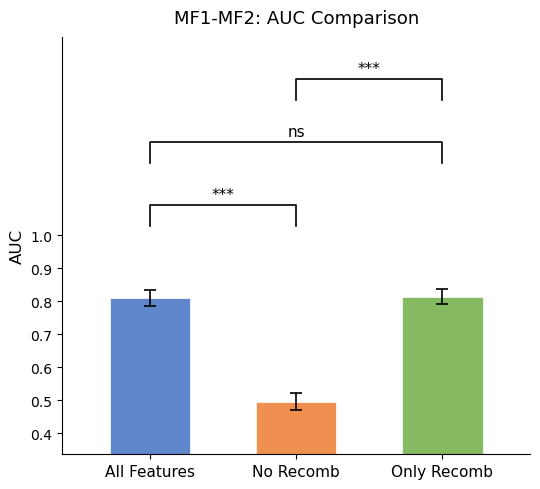

Saved AUC bar plot for Group mf1_mf2_all


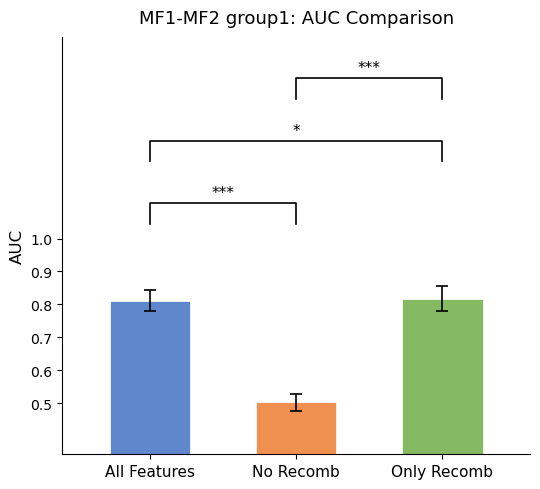

Saved AUC bar plot for Group mf1_mf2_groupI

All AUC bar plots saved.


In [8]:
# ============================================================
# CELL 8: AUC BAR PLOTS — one figure per group
#
# Significance brackets use FDR-corrected DeLong p-values.
# ============================================================

CUSTOM_TITLES = [
    "LF-MF1: AUC Comparison",
    "LF-MF1 group1: AUC Comparison",
    "LF-MF2: AUC Comparison",
    "LF-MF2 group1: AUC Comparison",
    "MF1-MF2: AUC Comparison",
    "MF1-MF2 group1: AUC Comparison",
]

BAR_WIDTH = 0.55
BAR_X     = [0, 1, 2]

for group, current_title in zip(GROUPS, CUSTOM_TITLES):

    fig, ax = plt.subplots(figsize=(5.5, 5))

    means = [auc_summary[group][c][0] for c in CONDITION_KEYS]
    stds  = [auc_summary[group][c][1] for c in CONDITION_KEYS]

    bars = ax.bar(BAR_X, means,
                  width=BAR_WIDTH,
                  color=CONDITION_COLORS,
                  alpha=0.85,
                  edgecolor='white',
                  linewidth=0.6,
                  zorder=2)

    ax.errorbar(BAR_X, means, yerr=stds,
                fmt='none', color='black',
                capsize=4, capthick=1.2,
                elinewidth=1.2, zorder=3)

    # --- Significance brackets (FDR-corrected DeLong) ---
    y_top   = max(m + s for m, s in zip(means, stds))
    y_range = max(means) - min(means)
    spacing = max(y_range, 0.02)

    # All Features vs No Recomb
    row_1 = results_df[
        (results_df.group == group) &
        (results_df.metric == "AUC") &
        (results_df.cond_b == "no_recomb")
    ].iloc[0]
    y1 = y_top + spacing * 0.6
    draw_bracket(ax, 0, 1, y1, spacing * 0.20, row_1["significance"])

    # All Features vs Only Recomb
    row_2 = results_df[
        (results_df.group == group) &
        (results_df.metric == "AUC") &
        (results_df.cond_b == "recomb_only")
    ].iloc[0]
    y2 = y1 + spacing * 0.60
    draw_bracket(ax, 0, 2, y2, spacing * 0.20, row_2["significance"])

    # No Recomb vs Only Recomb
    row_3 = results_df[
        (results_df.group == group) &
        (results_df.metric == "AUC") &
        (results_df.cond_a == "no_recomb") &
        (results_df.cond_b == "recomb_only")
    ].iloc[0]
    y3 = y2 + spacing * 0.60
    draw_bracket(ax, 1, 2, y3, spacing * 0.20, row_3["significance"])
    
    # --- Axes formatting ---
    ax.set_xticks(BAR_X)
    ax.set_xticklabels(CONDITION_LABELS, fontsize=11)
    ax.set_ylabel('AUC', fontsize=12)
    ax.set_title(current_title, fontsize=13, pad=10)
    ax.set_xlim(-0.6, 2.6)
    
    # Keep the high limit for brackets
    ax.set_ylim(min(means) - spacing * 0.5, y3 + spacing * 0.60)
    
    # --- FIX: Define ticks explicitly to stop at 1.0 ---
    # We generate a range (e.g., 0.5 to 1.0) and filter out anything above 1.0
    y_start = np.floor(min(means) * 10) / 10 # Round down to nearest 0.1
    ticks = np.arange(y_start, 1.1, 0.1)     # Standard AUC increments
    ax.set_yticks([t for t in ticks if t <= 1.0001])
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    for ext in ['pdf', 'png']:
        fig.savefig(
            os.path.join(OUTPUT_DIR, f"{group}_auc_bar.{ext}"),
            dpi=300, bbox_inches='tight'
        )
    plt.show()
    plt.close()
    print(f"Saved AUC bar plot for Group {group}")

print('\nAll AUC bar plots saved.')

In [9]:
# ============================================================
# CELL 9: SUPPLEMENTARY TABLE — per-fold F1 scores
#
# Wide-format table: one row per fold per group,
# columns for each condition's F1 score.
# Intended for inclusion as a supplementary table.
# ============================================================

supp_rows = []
for group in GROUPS:
    for fold_i in range(10):
        row = {
            "group": GROUP_LABELS[group],
            "fold":  fold_i + 1
        }
        for cond_key in CONDITION_KEYS:
            label = CONDITIONS[cond_key]["label"].replace(" ", "_").lower()
            row[f"f1_{label}"] = round(fold_f1_data[group][cond_key][fold_i], 6)
        # Differences
        row["diff_all_vs_no_recomb"]   = round(
            fold_f1_data[group]["all_features"][fold_i]
            - fold_f1_data[group]["no_recomb"][fold_i], 6)
        row["diff_all_vs_recomb_only"] = round(
            fold_f1_data[group]["all_features"][fold_i]
            - fold_f1_data[group]["recomb_only"][fold_i], 6)
        supp_rows.append(row)

supp_df = pd.DataFrame(supp_rows)

supp_path = os.path.join(OUTPUT_DIR, "supplementary_fold_f1_scores.csv")
supp_df.to_csv(supp_path, index=False)

print(supp_df.to_string(index=False))
print(f"\nSupplementary fold F1 table saved to: {supp_path}")

            group  fold  f1_all_features  f1_no_recomb  f1_only_recomb  diff_all_vs_no_recomb  diff_all_vs_recomb_only
     LF–MF1 (All)     1         0.700405      0.529284        0.688259               0.171121                 0.012146
     LF–MF1 (All)     2         0.723577      0.576613        0.692308               0.146964                 0.031270
     LF–MF1 (All)     3         0.674948      0.550847        0.651546               0.124101                 0.023402
     LF–MF1 (All)     4         0.708595      0.563025        0.684874               0.145570                 0.023721
     LF–MF1 (All)     5         0.666667      0.533049        0.668094               0.133618                -0.001428
     LF–MF1 (All)     6         0.693790      0.569565        0.673820               0.124225                 0.019970
     LF–MF1 (All)     7         0.696356      0.533333        0.685832               0.163023                 0.010525
     LF–MF1 (All)     8         0.721116      0.

In [10]:
# ============================================================
# CELL 10: SUMMARY PRINT
# ============================================================

print('OUTPUT FILES')
print('=' * 60)
for f in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, f)
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {f:<50} {size_kb:>7.1f} KB')

OUTPUT FILES
  .ipynb_checkpoints                                     4.0 KB
  ablation_significance_results.csv                      3.3 KB
  ablation_significance_tests.ipynb                    398.4 KB
  lf_mf1_all_auc_bar.pdf                                13.7 KB
  lf_mf1_all_auc_bar.png                                61.6 KB
  lf_mf1_all_f1_strip.pdf                               25.1 KB
  lf_mf1_all_f1_strip.png                              191.1 KB
  lf_mf1_groupI_auc_bar.pdf                             14.2 KB
  lf_mf1_groupI_auc_bar.png                             64.3 KB
  lf_mf1_groupI_f1_strip.pdf                            25.5 KB
  lf_mf1_groupI_f1_strip.png                           174.5 KB
  lf_mf2_all_auc_bar.pdf                                13.7 KB
  lf_mf2_all_auc_bar.png                                61.1 KB
  lf_mf2_all_f1_strip.pdf                               25.4 KB
  lf_mf2_all_f1_strip.png                              176.8 KB
  lf_mf2_groupI_auc_bar.pdf